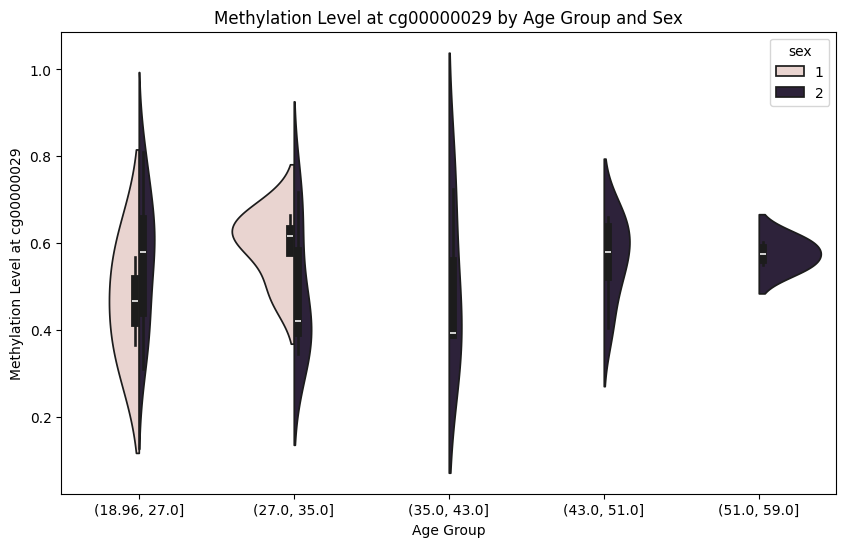

In [9]:
from biolearn.data_library import DataLibrary, GeoData
from biolearn.model_gallery import ModelGallery
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from biolearn.mortality import run_predictions, calculate_mortality_hazard_ratios
from biolearn.load import load_nhanes
year = 2010
df = load_nhanes(year)
df["years_until_death"] = df["months_until_death"] / 12

# Load clocks/models
Horvathv1 = ModelGallery().get("Horvathv1")
Hannum = ModelGallery().get("Hannum")
# Load dataframe
data = DataLibrary().get("GSE110554").load()

prediction = Hannum.predict

# # Make dictionary for mortality
# prediction_dict = {
#     "Horvathv1": "Predicted",
#     "Hannum": "Predicted"
# }

# predictions = run_predictions(data, prediction_dict)

dnam = data.dnam
meta = data.metadata

def plot_methylation_by_age_sex(data_dnam, data_meta, cpg_site):
    """
    Violin plot of DNAm levels at a specific CpG site by age group and sex.
    :param data_dnam: DataFrame with DNAm data.
    :param data_meta: DataFrame with metadata containing 'age' and 'sex'.
    :param cpg_site: CpG site ID to plot.
    """
    # Filter to samples with age and sex
    valid_meta = data_meta.dropna(subset=['age', 'sex'])
    methylation_data = data_dnam.loc[cpg_site, valid_meta.index]
    
    # Combine metadata and DNAm data for plotting
    plot_data = valid_meta.copy()
    plot_data['methylation'] = methylation_data
    plot_data['age_group'] = pd.cut(plot_data['age'], bins=5)  # Age group bins

    plt.figure(figsize=(10, 6))
    sns.violinplot(x='age_group', y='methylation', hue='sex', data=plot_data, split=True)
    plt.title(f'Methylation Level at {cpg_site} by Age Group and Sex')
    plt.xlabel('Age Group')
    plt.ylabel(f'Methylation Level at {cpg_site}')
    plt.show()

# List all CpG sites
c = dnam.index[0]

plot_methylation_by_age_sex(dnam, meta, c)



In [ ]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Create example DNAm data
num_samples = 20
num_cpg_sites = 10
sample_ids = [f"GSM{2998000 + i}" for i in range(num_samples)]
cpg_sites = [f"cg000000{i}" for i in range(num_cpg_sites)]

# Generate random methylation data (values between 0 and 1)
data_dnam = pd.DataFrame(
    np.random.rand(num_cpg_sites, num_samples),
    index=cpg_sites,
    columns=sample_ids
)

# Generate synthetic metadata
ages = np.random.randint(20, 80, size=num_samples)  # Random ages between 20 and 80
sexes = np.random.choice(['Male', 'Female'], size=num_samples)  # Randomly assign sex

# Create metadata DataFrame
data_meta = pd.DataFrame({
    'age': ages,
    'sex': sexes
}, index=sample_ids)


# Ensure necessary libraries are imported for plotting
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import interact

# Define the function for interactive selection and plotting, as detailed above
def plot_methylation_by_age_sex(data_dnam, data_meta, cpg_site):
    """
    Violin plot of DNAm levels at a specific CpG site by age group and sex.
    :param data_dnam: DataFrame with DNAm data (CpG sites as rows, sample IDs as columns).
    :param data_meta: DataFrame with metadata containing 'age' and 'sex'.
    :param cpg_site: String, the CpG site ID to plot.
    """
    if cpg_site not in data_dnam.index:
        print(f"CpG site '{cpg_site}' not found in DNAm data.")
        return

    # Extract methylation data for the specific CpG site
    methylation_data = data_dnam.loc[cpg_site]
    
    # Align metadata and methylation data
    valid_samples = data_meta.index.intersection(methylation_data.index)
    plot_data = data_meta.loc[valid_samples].copy()
    plot_data['methylation'] = methylation_data[valid_samples]
    plot_data['age_group'] = pd.cut(plot_data['age'], bins=5)  # Divide age into groups

    # Plot
    plt.figure(figsize=(10, 6))
    sns.violinplot(x='age_group', y='methylation', hue='sex', data=plot_data, split=True)
    plt.title(f'Methylation Level at {cpg_site} by Age Group and Sex')
    plt.xlabel('Age Group')
    plt.ylabel(f'Methylation Level at {cpg_site}')
    plt.show()

# Interactive plot setup
def interactive_cpg_plot(data_dnam, data_meta):
    cpg_sites = data_dnam.index.tolist()
    interact(lambda cpg_site: plot_methylation_by_age_sex(data_dnam, data_meta, cpg_site), cpg_site=cpg_sites)

# Run the interactive plotting function with example data




In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_methylation_by_age_sex_multiple(datasets, cpg_site, age_bins=5):
"""
    Visualizes methylation levels at a specific CpG site by age group and sex, across multiple datasets.

    Parameters:
    - datasets (list of tuples): Each tuple contains two DataFrames, (data_dnam, data_meta).
        * data_dnam: DNAm data with CpG sites as rows and samples as columns.
        * data_meta: Metadata with sample IDs as index, containing 'age' and 'sex' columns.
    - cpg_site (str): CpG site ID to visualize.
    - age_bins (int): Number of age bins for grouping, default is 5.

    Output:
    - Displays a combined violin plot of methylation levels for the specified CpG site, grouped by age and split by sex across datasets.
    """

    # Initialize a list to collect dnam from all datasets

    

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_methylation_by_age_sex_multiple(datasets, cpg_site, age_bins=5):
    """
    Visualizes methylation levels at a specific CpG site by age group and sex, across multiple datasets.

    Parameters:
    - datasets (list of tuples): Each tuple contains two DataFrames, (data_dnam, data_meta).
        * data_dnam: DNAm data with CpG sites as rows and samples as columns.
        * data_meta: Metadata with sample IDs as index, containing 'age' and 'sex' columns.
    - cpg_site (str): CpG site ID to visualize.
    - age_bins (int): Number of age bins for grouping, default is 5.

    Output:
    - Displays a combined violin plot of methylation levels for the specified CpG site, grouped by age and split by sex across datasets.
    """

    # Initialize a list to collect methylation data from all datasets
    combined_data = []

    for i, (data_dnam, data_meta) in enumerate(datasets):
        # Check if CpG site is in current dataset
        if cpg_site not in data_dnam.index:
            print(f"Warning: CpG site '{cpg_site}' not found in dataset {i + 1}. Skipping this dataset.")
            continue
        
        # Extract methylation data for the specific CpG site
        methylation_data = data_dnam.loc[cpg_site]
        
        # Align metadata and methylation data by sample ID
        valid_samples = data_meta.index.intersection(methylation_data.index)
        plot_data = data_meta.loc[valid_samples].copy()
        plot_data['methylation'] = methylation_data[valid_samples]

        # Add dataset identifier for tracking
        plot_data['dataset'] = f'Dataset {i + 1}'

        # Append to combined data list
        combined_data.append(plot_data)

    # Concatenate all datasets into a single DataFrame
    combined_data = pd.concat(combined_data, axis=0)
    
    # Create age groups for consistent grouping across datasets
    combined_data['age_group'] = pd.cut(combined_data['age'], bins=age_bins)

    # Plot
    plt.figure(figsize=(14, 8))
    sns.violinplot(
        x='age_group', 
        y='methylation', 
        hue='sex', 
        data=combined_data, 
        split=True, 
        palette="Set2"
    )
    plt.title(f'Methylation Level at {cpg_site} by Age Group and Sex Across Multiple Datasets')
    plt.xlabel('Age Group')
    plt.ylabel(f'Methylation Level at {cpg_site}')
    plt.legend(title="Sex")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



NameError: name 'data_dnam_1' is not defined

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


def plot_cell_type_aging_trajectory(data, age_column='Age', deconvolute_method=DeconvoluteBloodEPIC, cell_types=None, age_range=None):
    """
    Plot cell type proportion changes over age using deconvolution from DNA methylation data.
    
    Parameters:
        data (pd.DataFrame): The dataset containing DNA methylation data with age and sample IDs.
        age_column (str): The name of the column containing chronological age of individuals.
        deconvolute_method: The deconvolution method used for estimating cell type proportions.
        cell_types (list): List of cell types to include in the plot (default: None, which plots all available).
        age_range (tuple): The range of ages to include in the plot (e.g., (20, 80)). If None, use the full range.
    
    Returns:
        plt.Figure: A plot showing the trajectory of cell type proportions across the age range.
    """
    # Perform deconvolution to estimate cell type proportions
    decon_results = deconvolute_method(data)
    
    # Convert deconvolution results into a DataFrame for easy plotting
    decon_df = pd.DataFrame(decon_results, columns=['Neutrophils', 'Monocytes', 'NK_Cells', 'B_Cells', 'CD4_T_Cells', 'CD8_T_Cells'])
    decon_df[age_column] = data[age_column]
    
    # Filter by the specified age range, if provided
    if age_range:
        decon_df = decon_df[(decon_df[age_column] >= age_range[0]) & (decon_df[age_column] <= age_range[1])]
    
    # If specific cell types are provided, filter the DataFrame to include only those
    if cell_types:
        decon_df = decon_df[cell_types + [age_column]]
    
    # Melt the DataFrame for easier plotting with seaborn
    melted_df = pd.melt(decon_df, id_vars=[age_column], var_name='Cell_Type', value_name='Proportion')
    
    # Plot the cell type trajectories
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=melted_df, x=age_column, y='Proportion', hue='Cell_Type', marker="o")
    
    # Add labels and title
    plt.title('Cell Type Proportion Changes Across Age')
    plt.xlabel('Age (Years)')
    plt.ylabel('Proportion of Cell Types')
    plt.legend(title='Cell Types')
    
    plt.grid(True)
    plt.tight_layout()
    
    # Show the plot
    plt.show()

# Example usage
# Assuming we have a DataFrame `methylation_data` with DNA methylation data and an 'Age' column
# plot_cell_type_aging_trajectory(methylation_data)
